In [33]:
import os
import sys
import pickle
import gzip
import csv 


import numpy as np
import pandas as pd
import multiprocessing as mp

from matplotlib import pyplot as plt
import matplotlib.colors

pd.options.mode.chained_assignment = None

In [ ]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
sc.set_figure_params(dpi_save = 600)

# Load objs

In [2]:
leaf_to_subclass_dict_path = "./objs/leaf_to_subclass.pkl"
leaf_to_subclass_dict = pickle.load(open(leaf_to_subclass_dict_path, "rb"))

leaf_to_subclass_dict_inh_grouped={}
for leaf, subclass in leaf_to_subclass_dict.items():
    if leaf.startswith("Inh"):
        leaf_to_subclass_dict_inh_grouped[leaf] = "Inh"
    else:
        leaf_to_subclass_dict_inh_grouped[leaf] = subclass

unique_layer_groups = np.unique(list(leaf_to_subclass_dict_inh_grouped.values()))
layer_to_leaf_dict = {layer: [leaf for leaf in leaf_to_subclass_dict_inh_grouped if leaf_to_subclass_dict_inh_grouped[leaf] == layer] for layer in unique_layer_groups}
layer_to_leaf_tup_list = [(layer, layer_to_leaf_dict[layer]) for layer in unique_layer_groups]
layer_to_leaf_tup_list.append(("null", ["Glia", "empty", "unassigned", "Inh"]))


In [3]:
vt_name_to_observed_path = "./objs/vt_freq_objs.pkl"
vt_density_obj = pickle.load(open(vt_name_to_observed_path, "rb"))
vt_name_to_density=vt_density_obj["vt_name_to_density"]
vt_name_to_observed = vt_density_obj["vt_name_to_n_observed"]

aav_pool_set = vt_name_to_observed.keys()


In [4]:
vt_objs_path = "./objs/vt_processed_objs_select_cols.pkl"

vt_objs = pickle.load(open(vt_objs_path, "rb"))

v1_vt_obj = vt_objs["v1"]

aca_vt_obj = vt_objs["aca"]


In [7]:
projection_objs_path = "./objs/grouped_projection_vts.pkl"
projection_objs = pickle.load(open(projection_objs_path, "rb"))


In [8]:
v1_projs = projection_objs["v1"]
aca_projs = projection_objs["aca"]
cp_only_projs = projection_objs["cp_sub_dissects"]


In [10]:
# cp_only_grouped = set()
# for region, set_cp in cp_only_projs.items():
#     cp_only_grouped.update(set_cp)
# cp_only_grouped == v1_projs["CP"]

In [12]:
class_type_col = "class"
subclass_type_col = "subclass"
cluster_type_col="cluster"
cluster_grouped_col = "cluster_grouped"

# Functions

In [24]:
def create_umi_dist_empty_called(dialout_obj, class_col="class", mscar_col="is_mscar", empty_col="is_empty", proj_vts_all = None, title_base="", max_bin=10):
    m_mat = dialout_obj["m_mat"]
    meta = dialout_obj["meta"]
    
    is_empty = meta[empty_col]
    neuron_classes = set(["Ex", "Inh"])
    is_neuron = meta[class_col].isin(neuron_classes)

    if mscar_col is not None:
        print("subset_mscar")
        is_neuron = is_neuron & meta[mscar_col]
    
    empty_m_mat = m_mat[is_empty, :]
    neuron_m_mat = m_mat[is_neuron, :]
    
    neuron_umi_dist = neuron_m_mat.data
    empty_umi_dist = empty_m_mat.data
    
    neuron_mean = round(np.mean(neuron_umi_dist), 3)
    empty_mean = round(np.mean(empty_umi_dist), 3)

    neuron_prop1 = round(np.mean(neuron_umi_dist == 1), 3)
    empty_prop1 = round(np.mean(empty_umi_dist == 1), 3)

    neuron_median = np.median(neuron_umi_dist)
    empty_median = np.median(empty_umi_dist)
    
    n_neuron_umis = len(neuron_umi_dist)
    n_empty_umis = len(empty_umi_dist)
    
    sampled_neuron = np.random.choice(neuron_umi_dist, len(empty_umi_dist))

    title=f"{title_base}\nNeuron: Mean: {neuron_mean} Median: {neuron_median} Prop1: {neuron_prop1}\nEmpty: Mean: {empty_mean} Median: {empty_median} Prop1: {empty_prop1}"
    
    fig, ax = plt.subplots()
    neuron_dist = ax.hist(sampled_neuron, color="green", bins=range(1, max_bin), label="Neuron UMI Dist")
    empty_dist = ax.hist(empty_umi_dist, color="orange", bins=range(1, max_bin), label="Empty UMI Dist")
    ax.set_yscale("log")
    ax.set_title(title)
    ax.legend()
    fig.show()

    r = {
        "neuron": neuron_umi_dist,
        "empty": empty_umi_dist
    }
    return r

def create_likelihood_function(neuron_umi_dist, empty_umi_dist, cutoff=5):

    n_vts_neuron = len(neuron_umi_dist)
    neuron_counts = Counter(neuron_umi_dist)
    neuron_pmf = {key: value / n_vts_neuron for key, value in neuron_counts.items()}
    
    n_vts_empty = len(empty_umi_dist)
    empty_counts = Counter(empty_umi_dist)
    empty_pmf = {key: value / n_vts_empty for key, value in empty_counts.items()}
    
    unique_counts_observed = set(neuron_pmf.keys())
    unique_counts_observed.update(empty_pmf.keys())
    unique_counts_observed_lis = list(unique_counts_observed)
    
    counts_both_seen = set(neuron_pmf.keys()).intersection(empty_pmf.keys())
    likelihood_vals = {}
    for count_n in counts_both_seen:
        mass_empty = empty_pmf.get(count_n, 0)
        mass_called = neuron_pmf.get(count_n, 0)
        if mass_called == 0 and mass_empty != 0:
            # define minimum lr if not defined
            likelihood_ratio = 0.0001
        else:
            likelihood_ratio = mass_empty / mass_called
    
        likelihood_vals[count_n] = likelihood_ratio

    # Likelihood function
    # set upper bound for comp
    # higher than needed
    max_umi_seen = 200
    umi_count_to_likelihood_score = {}
    for i in range(1,max_umi_seen):

        if i > cutoff:
            val = likelihood_vals[cutoff]
            umi_count_to_likelihood_score[i] = val
        else:
            val = likelihood_vals[i]
            umi_count_to_likelihood_score[i] = val

    res = {
        "empty_density": empty_pmf, 
        "neuron_density": neuron_pmf,
        "likelihood_function": umi_count_to_likelihood_score
    }
    
    return res

def create_cell_vt_df(dialout):
    m_mat = dialout["m_mat"]
    cell_bcs = dialout["cell_bcs"]
    vts = dialout["vts"]
    meta=dialout["meta"]
    vt_df_dict = {"vt": [], "cell": [], "umi_support": []}
    nz_rows, nz_cols = np.nonzero(m_mat)
    for row_inx, col_inx in zip(nz_rows, nz_cols):
        cell_id=cell_bcs[row_inx]
        vt_id = vts[col_inx]
        umi_support = m_mat[row_inx, col_inx]
    
        vt_df_dict["vt"].append(vt_id)
        vt_df_dict["cell"].append(cell_id)
        vt_df_dict["umi_support"].append(umi_support)
    
    vt_df = pd.DataFrame(vt_df_dict)
    vt_df["cell_vt"] = vt_df["cell"] + vt_df["vt"]
    vt_df = pd.merge(vt_df, meta, left_on="cell", right_index=True, how="inner")
    
    return vt_df

def add_prob_infection_background_prior(vt_df, cell_bc_to_background_rate, likelihood_function):

    vt_df["prob_background"] = vt_df.apply(lambda row: compute_delivered_prob_from_row(row, cell_bc_to_background_rate, likelihood_function), axis=1)
    vt_df["prob_infection"] = 1 - vt_df["prob_background"]


def compute_delivered_prob_from_row(cell_vt_row, cell_bc_background_rate, likelihood_func):
    
    is_empty = cell_vt_row["is_empty"]
    if is_empty:
        return 0
    
    umi_count = cell_vt_row['umi_support']
    cell_bc = cell_vt_row["cell"]
    
    prior = cell_bc_background_rate[cell_bc]
    lr = likelihood_func[umi_count]
    pl = lr * prior
    prob = pl / (pl + (1-prior))
    
    return prob

def estimate_transduction_params(dialout_obj, all_vts_proj_site):
    meta = dialout_obj["meta"]
    m_mat = dialout_obj["m_mat"]

    is_mscar = meta["is_mscar"]
    n_cells_mscar = np.sum(is_mscar)
    m_mat_mscar = m_mat[is_mscar,:]

    is_empty = meta["is_empty"]
    m_mat_empty = m_mat[is_empty,:]

    vts = np.array(dialout_obj["vts"])
    vt_is_observed = np.array((m_mat_mscar > 0).sum(axis=0)).flatten().astype(bool)
    observed_vts_set = set(vts[vt_is_observed])
    proj_vts_accounted_for = observed_vts_set.intersection(all_vts_proj_site)
    n_vts_accounted_for = len(proj_vts_accounted_for)
    n_vts_proj_total = len(all_vts_proj_site)

    prop_accounted_for = n_vts_accounted_for / n_vts_proj_total
    naive_n = n_cells_mscar / prop_accounted_for

    mean_vts_per_mscar = np.mean((m_mat_mscar > 0).sum(axis=1))
    mean_vts_per_empty= np.mean((m_mat_empty > 0).sum(axis=1))
    expected_vt_infections_per_cell = mean_vts_per_mscar - mean_vts_per_empty
    n_vts_infected_total = mean_vts_per_mscar * naive_n
    
    param_obj = {
        "n_vts_infected_total": n_vts_infected_total,
        "vts_per_cell": expected_vt_infections_per_cell,
        "n_cells_infected_total": naive_n,
        "prop_accounted_for": prop_accounted_for
    }
    return param_obj

def create_scoring_df(vt_name_to_observed, n_cells_estimate, vts_per_cell):
    n_vts_sampled=n_cells_estimate*vts_per_cell
    n_observations_total = np.sum(list(vt_name_to_observed.values()))

    prob_no_observance_per_vt = {}
    prob_observance_df_dict = {"vt": [], "n_observances": [],  "prob": []}
    for inx, (vt, n_observations) in enumerate(vt_name_to_observed.items()):

        prop_aav_pool = n_observations / n_observations_total

        expected_number_sampling = ((n_cells_estimate - 1) * vts_per_cell) * prop_aav_pool
        prob = 1/(expected_number_sampling + 1)

        prob_observance_df_dict["vt"].append(vt)
        prob_observance_df_dict["n_observances"].append(n_observations)
        prob_observance_df_dict["prob"].append(prob)

    prob_never_seen_df = pd.DataFrame(prob_observance_df_dict)

    prob_never_seen_df["expected_cell_deliveries"] = (prob_never_seen_df["n_observances"] / n_observations_total) * n_vts_sampled

    return prob_never_seen_df

def create_glia_col(vt_df, col_mod, class_pred_col=class_type_col):
    glia_classes = set({"Oligo", "Astro", "Micro", "Macro", "OPC", "Endo", "Ependymal", "Ng", "Fibro"})
    is_glia_pred = vt_df[class_pred_col].isin(glia_classes)
    vt_df.loc[is_glia_pred, col_mod] = "Glia"

def create_inh_col(vt_df, col_mod, class_pred_col=class_type_col):
    is_inh_pred = vt_df[class_pred_col] == "Inh"
    vt_df.loc[is_inh_pred, col_mod] = "Inh"




subset_mscar
subset_mscar


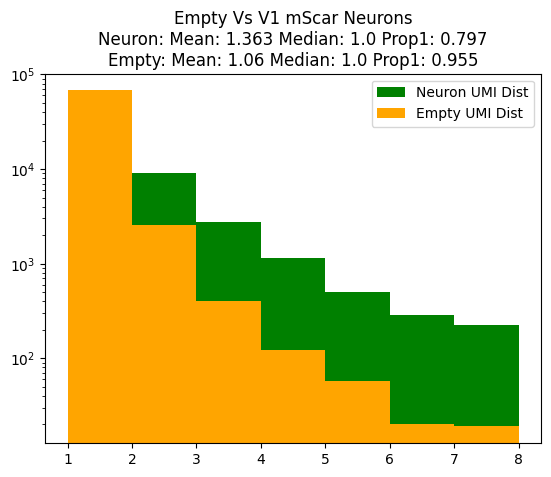

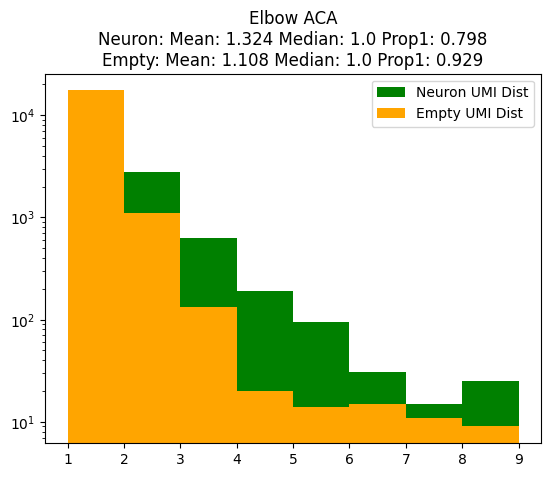

In [15]:
elbow_v1_umi_dist = create_umi_dist_empty_called(v1_vt_obj, title_base="Empty Vs V1 mScar Neurons", max_bin=9)

elbow_aca_umi_dist = create_umi_dist_empty_called(aca_vt_obj, title_base="Elbow ACA")

neuron_dist_aca_elbow = elbow_aca_umi_dist["neuron"]
empty_dist_aca_elbow = elbow_aca_umi_dist["empty"]
likelihood_function_elbow_aca = create_likelihood_function(neuron_dist_aca_elbow, empty_dist_aca_elbow, cutoff=5)
likelihood_function_elbow_aca  =likelihood_function_elbow_aca["likelihood_function"]


neuron_dist_v1_elbow = elbow_v1_umi_dist["neuron"]
empty_dist_v1_elbow = elbow_v1_umi_dist["empty"]
likelihood_function_elbow_v1 = create_likelihood_function(neuron_dist_v1_elbow, empty_dist_v1_elbow, cutoff=5)
likelihood_function_elbow_v1 = likelihood_function_elbow_v1["likelihood_function"]


In [16]:
all_v1_projs = set()
for region, vts in v1_projs.items():
    all_v1_projs.update(vts)

all_aca_projs = set()
for region, vts in aca_projs.items():
    all_aca_projs.update(vts)

aca_N_params = estimate_transduction_params(aca_vt_obj, all_aca_projs)
v1_N_params = estimate_transduction_params(v1_vt_obj, all_v1_projs)

aca_vt_scores = create_scoring_df(vt_name_to_observed=vt_name_to_observed, n_cells_estimate = aca_N_params["n_cells_infected_total"], vts_per_cell = aca_N_params["vts_per_cell"])

v1_vt_scores = create_scoring_df(vt_name_to_observed=vt_name_to_observed, n_cells_estimate = v1_N_params["n_cells_infected_total"], vts_per_cell = v1_N_params["vts_per_cell"])


In [ ]:
v1_vt_scores_samp = v1_vt_scores.iloc[np.random.choice(v1_vt_scores.shape[0], 40000, replace=False)]
v1_vt_scores_samp_sorted = v1_vt_scores_samp.sort_values("n_observances")
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(v1_vt_scores_samp_sorted["n_observances"], v1_vt_scores_samp_sorted["prob"])
ax.set_xscale("log")
ax.grid(False)
ax.set_ylabel("Probability of attribution to cell observed")
ax.set_xlabel("Observations in sequenced pool")

In [18]:
cell_vt_df_elbow_v1 = create_cell_vt_df(v1_vt_obj)
cell_vt_df_elbow_aca = create_cell_vt_df(aca_vt_obj)


In [19]:
### merge with scores, subset to cells with mscar only###
aca_cell_vt_df = pd.merge(cell_vt_df_elbow_aca, aca_vt_scores, on="vt", how="inner")
aca_cell_vt_df = aca_cell_vt_df[aca_cell_vt_df["is_mscar"]]

v1_cell_vt_df = pd.merge(cell_vt_df_elbow_v1, v1_vt_scores, on="vt", how="inner")
v1_cell_vt_df = v1_cell_vt_df[v1_cell_vt_df["is_mscar"]]


In [21]:
# Load cellular bg rates
bg_rates_obj_path = "./objs/cellular_bg_rates.pkl"
bg_rates_obj = pickle.load(open(bg_rates_obj_path, "rb"))

v1_cell_bc_to_background_prior_dict = bg_rates_obj["v1"]
aca_cell_bc_to_background_prior_dict = bg_rates_obj["aca"]

bg_rates_obj.keys()

dict_keys(['v1', 'aca'])

In [23]:
add_prob_infection_background_prior(v1_cell_vt_df, v1_cell_bc_to_background_prior_dict, likelihood_function_elbow_v1)
add_prob_infection_background_prior(aca_cell_vt_df, aca_cell_bc_to_background_prior_dict, likelihood_function_elbow_aca)

v1_cell_vt_df["prob_attr"] = v1_cell_vt_df["prob_infection"] * v1_cell_vt_df["prob"]

aca_cell_vt_df["prob_attr"] = aca_cell_vt_df["prob_infection"] * aca_cell_vt_df["prob"]


In [25]:
subclass_to_id = {
    "007_L2-3_IT_CTX_Glut": "L2/3 IT",
    "006_L4-5_IT_CTX_Glut": "L4/5 IT",
    "005_L5_IT_CTX_Glut": "L5 IT",
    "004_L6_IT_CTX_Glut": "L6 IT",
    "022_L5_ET_CTX_Glut": "L5 ET",
    "030_L6_CT_CTX_Glut": "L6 CT",
    "032_L5_NP_CTX_Glut": "L5 NP",
    "029_L6b_CTX_Glut": "L6b",
    "Inh": "Inh"
}

# map subclass cell type name into simpler name
v1_cell_vt_df["subclass_visual"] = v1_cell_vt_df[subclass_type_col].apply(lambda x:subclass_to_id.get(x, x)) 
aca_cell_vt_df["subclass_visual"] = aca_cell_vt_df[subclass_type_col].apply(lambda x:subclass_to_id.get(x, x)) 


In [28]:
create_glia_col(v1_cell_vt_df, "subclass_visual")
create_glia_col(v1_cell_vt_df, cluster_grouped_col)
create_inh_col(v1_cell_vt_df, "subclass_visual")

create_glia_col(aca_cell_vt_df, "subclass_visual")
create_glia_col(aca_cell_vt_df, cluster_grouped_col)
create_inh_col(aca_cell_vt_df, "subclass_visual")


In [37]:
v1_cell_vt_df.to_csv("./objs/VTDFs/v1_vt_df.csv", index=False)
aca_cell_vt_df.to_csv("./objs/VTDFs/aca_vt_df.csv", index=False)